In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os 
from astropy.io import ascii


plt.style.use('plot_styles.mplstyle_new')

In [2]:
km_s = 1e5 #* cm/s
G = 6.67430e-8
Msun = 1.989e33
Lsun = 3.828e33
Rsun = 6.96e10

secinyear = 3.154e7
secinday = 86400

Mpc_cm = 3.086*10**24 #Mpc converted to cm
Jansky = 1e-23 #erg/s/cm^2/Hz

In [3]:
cendes_event_distances = ascii.read("cendes_distances.txt",delimiter='\t')

In [4]:
cendes2024=ascii.read("cendes_mrt.txt")

In [5]:
cendes2024.add_column(col=-1,name='Distance (Mpc)')
for i,object_name in enumerate(cendes_event_distances['Object']):
    if object_name in np.unique(cendes2024['Object']):
        print(object_name)
        index = np.where(cendes2024['Object'] == object_name)[0][0]
        # print(cendes2024['Object'][index])
        # print(index)
        cendes2024['Distance (Mpc)'][index] = cendes_event_distances['Distance (Mpc)'][i]

iPTF16fnl
AT2019dsg
ASASSN-14ae
PS16dtm
AT2018zr
AT2018dyb
AT2018hco
AT2019ehz
AT2019eve
AT2019teq
AT2020neh
DES14C1kia
iPTF15af
iPTF16axa
AT2017eqx
AT2018fyk
AT2018lna


In [6]:
cendes2024

Object,Tel,Code,Date,dt,Freq,l_S,S,e_S,Distance (Mpc)
,,,,d,GHz,,mJy,mJy,
str11,str7,str18,str12,int64,str5,str1,float64,float64,int64
iPTF16fnl,VLA,20A-492,2020 May 24,1365,6,--,0.045,0.001,71
iPTF16fnl,VLA,21A-303,2021 Jun 15,1752,3,<,0.514,--,-1
iPTF16fnl,VLA,21A-303,2021 Jun 15,1752,5,--,0.028,0.008,-1
iPTF16fnl,VLA,21A-303,2021 Jun 15,1752,7,--,0.031,0.007,-1
iPTF16fnl,VLA,21A-303,2021 Jun 15,1752,9,--,0.024,0.006,-1
iPTF16fnl,VLA,21A-303,2021 Jun 15,1752,11,--,0.023,0.008,-1
AT2019dsg,VLA,21A-303,2021 Jun 12,796,1.25,<,0.514,--,230
AT2019dsg,VLA,21A-303,2021 Jun 12,796,1.75,--,0.114,0.033,-1


In [7]:
dict_events = {}

for name in np.unique(np.array(cendes2024['Object'])):
    print(name)
    dt_array_temp = np.array([])
    freq_array_temp = np.array([])
    fluxdensity_array_temp = np.array([])
    err_fluxdensity_array_temp = np.array([])
    luminosity_array_temp = np.array([])
    err_luminosity_array_temp = np.array([])
    for i in range(len(cendes2024['Object'])):
        if cendes2024['Object'][i] == name:
            try:
                float(cendes2024['Freq'][i])
            except:
                continue
            # for i,object_name in enumerate(cendes_event_distances['Object']):
            index = np.where(name == cendes_event_distances['Object'])[0][0]
            # print(cendes_event_distances['Object'][index])
            lum_fac = 4*np.pi*(cendes_event_distances['Distance (Mpc)'][index]*Mpc_cm)**2 * Jansky * 1e-3
            # print(cendes2024['Object'][i], cendes2024['dt'][i],cendes2024['Freq'][i],cendes2024['S'][i],cendes2024['e_S'][i])
            dt_array_temp = np.append(dt_array_temp, cendes2024['dt'][i])
            freq_array_temp = np.append(freq_array_temp, float(cendes2024['Freq'][i]))
            fluxdensity_array_temp = np.append(fluxdensity_array_temp, cendes2024['S'][i])
            err_fluxdensity_array_temp = np.append(err_fluxdensity_array_temp, cendes2024['e_S'][i])
            luminosity_array_temp = np.append(luminosity_array_temp, cendes2024['S'][i]*lum_fac)
            err_luminosity_array_temp = np.append(err_luminosity_array_temp, cendes2024['e_S'][i]*lum_fac)
    dict_events[name] = {'times (d)': dt_array_temp, 'freq (GHz)': freq_array_temp, 'flux density (mJy)': fluxdensity_array_temp, 'error (mJy)': err_fluxdensity_array_temp,
                         'Lnu (erg/s/Hz)': luminosity_array_temp, 'error (erg/s/Hz)': err_luminosity_array_temp}

ASASSN-14ae
AT2017eqx
AT2018dyb
AT2018fyk
AT2018hco
AT2018lna
AT2018zr
AT2019dsg
AT2019ehz
AT2019eve
AT2019teq
AT2020neh
DES14C1kia
PS16dtm
iPTF15af
iPTF16axa
iPTF16fnl


In [8]:
dict_events['PS16dtm']['times (d)']

array([  54.,  144.,  326.,  372.,  984., 1405., 1485., 1767., 1767.,
       1767., 1767., 1767., 2291., 2291., 2291., 2291., 2291., 2291.,
       2291., 2291.])

In [9]:
dict_events['PS16dtm']['freq (GHz)']

array([15.5  ,  6.   ,  3.   ,  6.   ,  0.887,  6.   ,  3.   ,  3.   ,
        5.   ,  7.   ,  9.   , 11.   ,  1.25 ,  1.75 ,  3.   ,  6.   ,
       10.   , 15.   , 20.   , 24.   ])

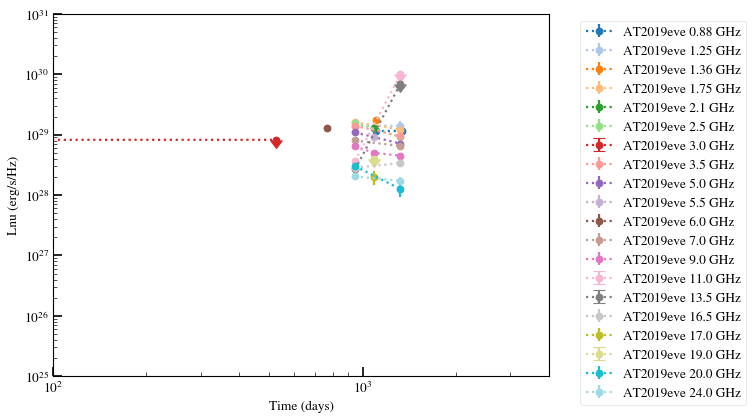

In [10]:
event_name = 'AT2019eve'

colors = plt.cm.tab20(np.linspace(0, 1, len(np.unique(dict_events[event_name]['freq (GHz)']))))
fig,ax = plt.subplots(figsize=(8, 6))
for j,freq in enumerate(np.unique(dict_events[event_name]['freq (GHz)'])):
    freq_array = np.array([],dtype=int)
    uplims_array = np.array([],dtype=bool)
    for i in range(len(dict_events[event_name]['freq (GHz)'])):
        if dict_events[event_name]['freq (GHz)'][i] == freq:
            # print(i)
            freq_array = np.append(freq_array,i)
            if dict_events[event_name]['error (mJy)'][i] == 0:
                uplims_array = np.append(uplims_array,True)
            else:
                uplims_array = np.append(uplims_array,False)
    ax.errorbar(dict_events[event_name]['times (d)'][freq_array], dict_events[event_name]['Lnu (erg/s/Hz)'][freq_array], 
                yerr=dict_events[event_name]['error (erg/s/Hz)'][freq_array], fmt='o',  uplims=uplims_array,
                ms=6, label=event_name+f' {freq} GHz',color=colors[j],linestyle=':')
                # unique=False
ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(1e2,4e3)
ax.set_ylim(1e25,1e31)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Lnu (erg/s/Hz)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# plotting data in some different units

flux (mJy)

In [11]:
plt.close('all')

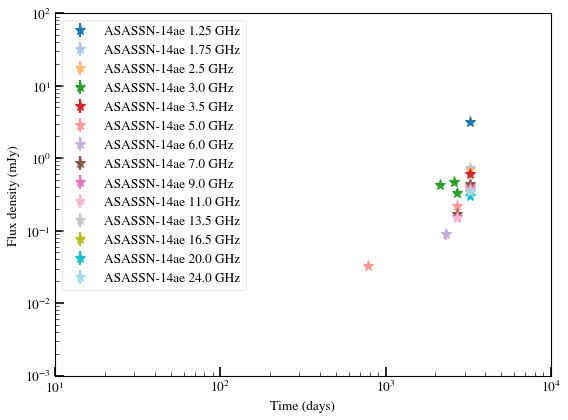

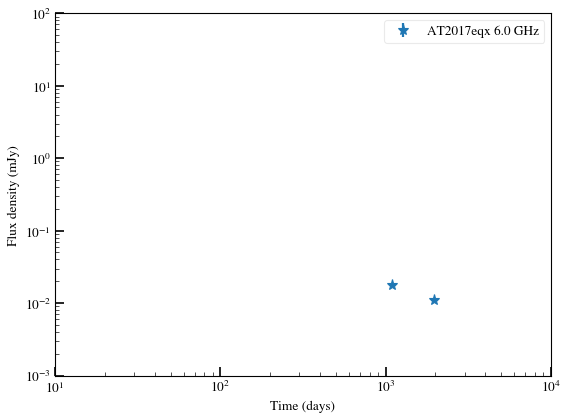

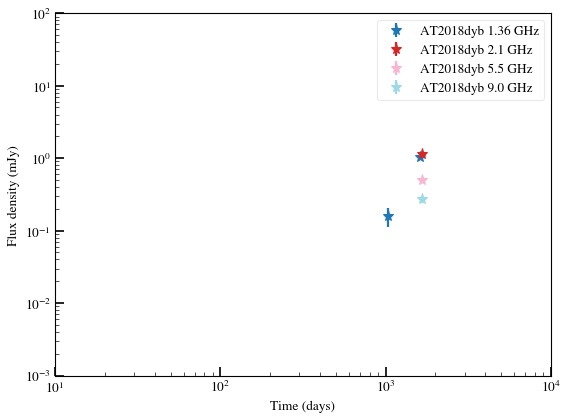

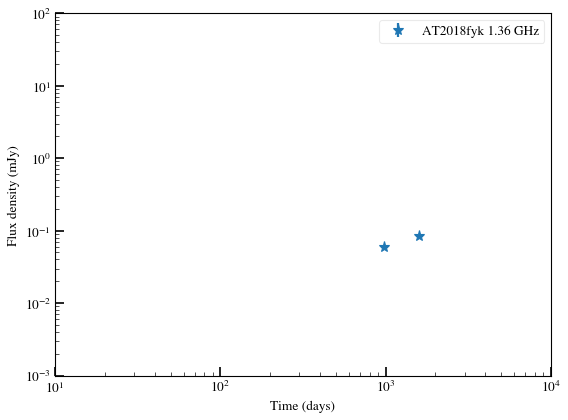

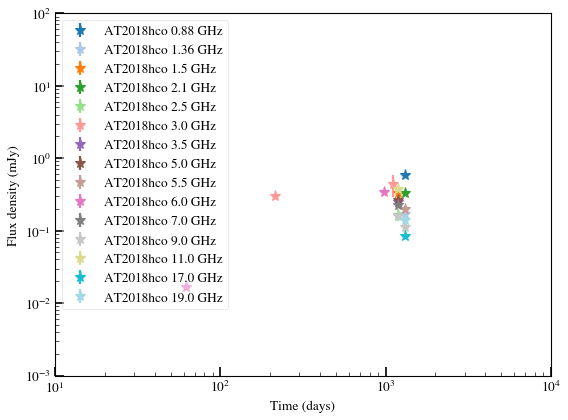

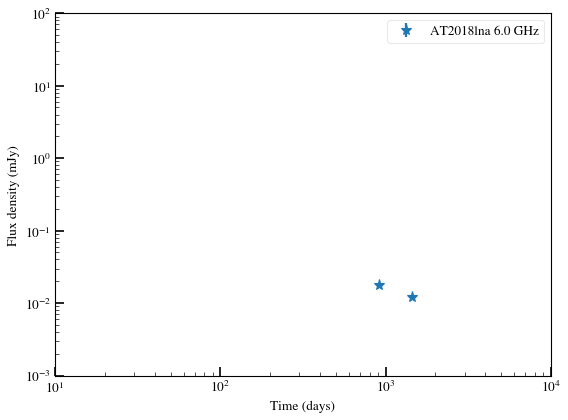

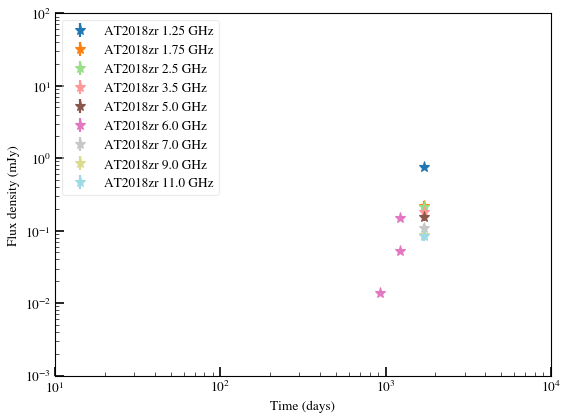

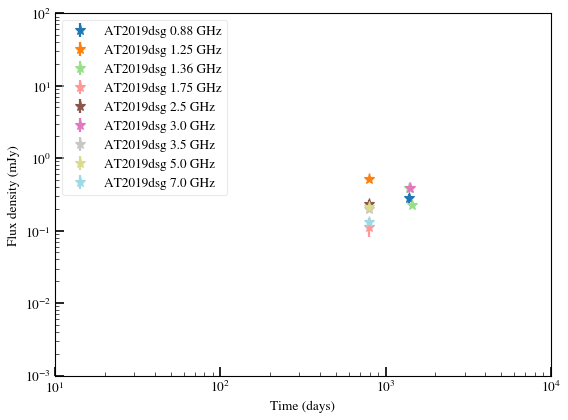

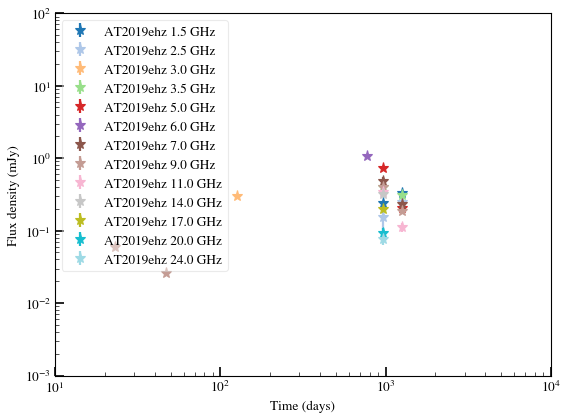

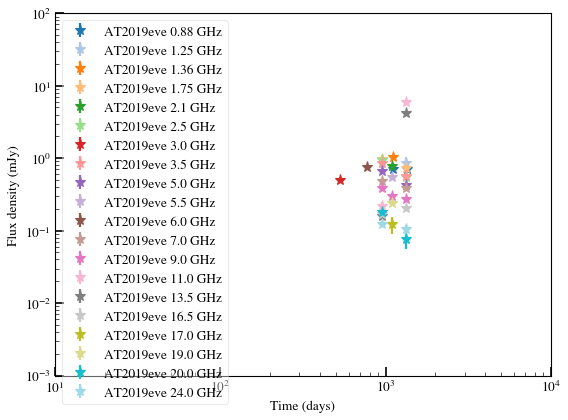

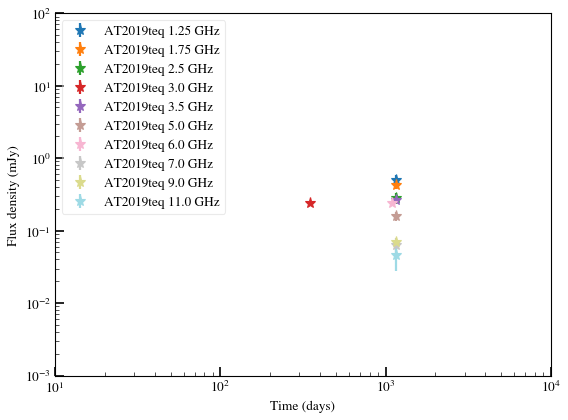

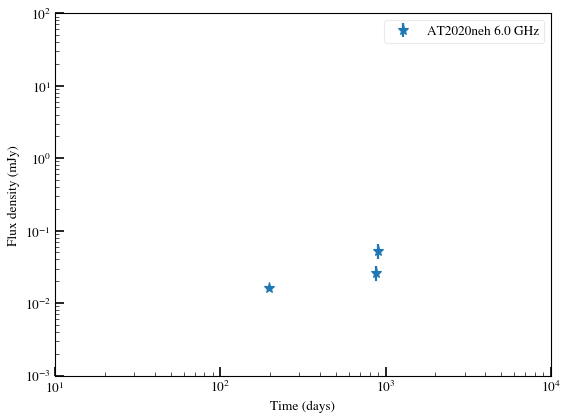

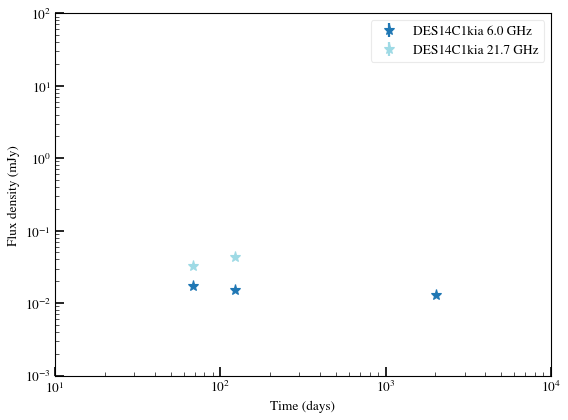

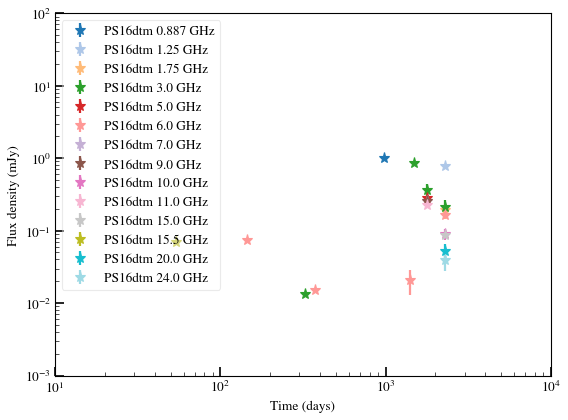

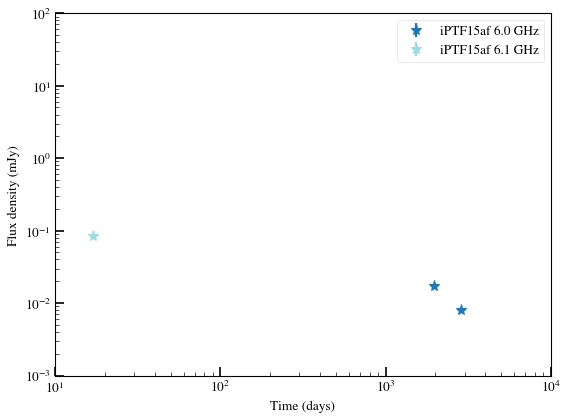

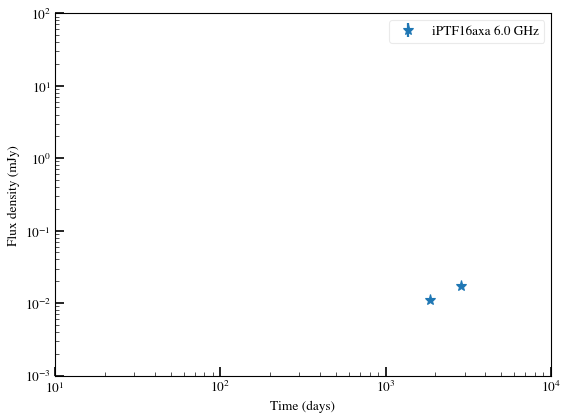

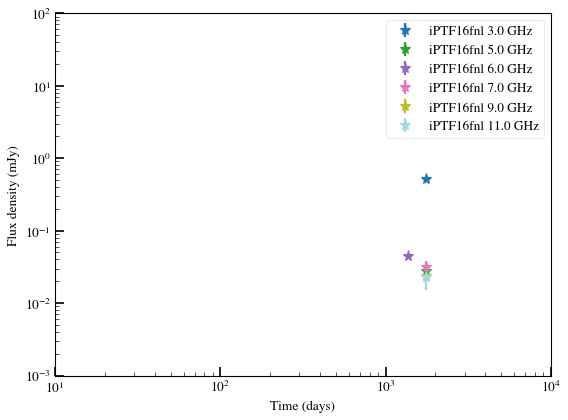

In [12]:
for event in dict_events.keys():
    # if event != 'ASASSN-14ae':
    #     continue
    colors_array = plt.cm.tab20(np.linspace(0, 1, len(np.unique(dict_events[event]['freq (GHz)']))))
    # print(len(np.unique(dict_events[event]['freq (GHz)'])))
    fig,ax = plt.subplots(figsize=(8, 6))
    for freq, color in zip(np.unique(dict_events[event]['freq (GHz)']), colors_array):
        # print(color,freq)
        unique = True
        for i in range(len(dict_events[event]['freq (GHz)'])):
            if dict_events[event]['freq (GHz)'][i] == freq:
                # print(freq,  dict_events[event]['flux density (mJy)'][i])
                # print(i,unique)
            #     print(dict_events[event]['freq (GHz)'][i],dict_events[event]['flux density (mJy)'][i],dict_events[event]['error (mJy)'][i])
                if unique:
                    label = f'{event} {freq} GHz'
                else:
                    label = None
                ax.errorbar(dict_events[event]['times (d)'][i], dict_events[event]['flux density (mJy)'][i], yerr=dict_events[event]['error (mJy)'][i], fmt='*', color=color, label=label)
                unique=False
    ax.set_xscale('log')
    ax.set_yscale('log')    
    ax.set_xlim(10,1e4)
    ax.set_ylim(1e-3,1e2)
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Flux density (mJy)')
    plt.legend()

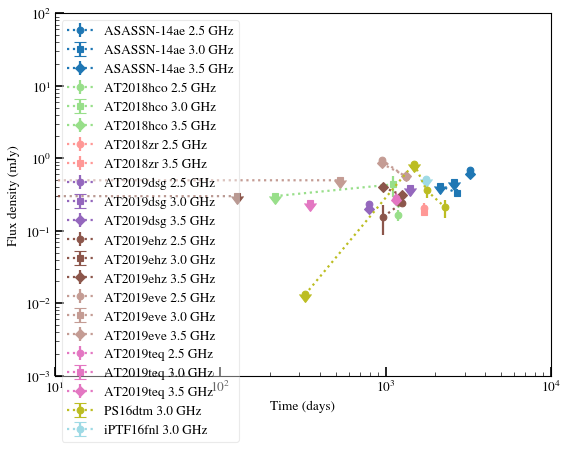

In [13]:
fig,ax = plt.subplots(figsize=(8, 6))
colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_events.keys())))
for event,color in zip(dict_events.keys(), colors_array):
    # if event != 'ASASSN-14ae':
    #     continue
    marker_array = ['o','s','D', '*','^','<','>','p','h','8']
    marker_num =0
    for freq in np.unique(dict_events[event]['freq (GHz)']):

        if np.abs(freq-3) > 0.5:
            continue

        freq_array = np.array([],dtype=int)
        uplims_array = np.array([],dtype=bool)
        for i in range(len(dict_events[event]['freq (GHz)'])):
            if dict_events[event]['freq (GHz)'][i] == freq:
                # print(i)
                freq_array = np.append(freq_array,i)
                if dict_events[event]['error (mJy)'][i] == 0:
                    uplims_array = np.append(uplims_array,True)
                else:
                    uplims_array = np.append(uplims_array,False)
        ax.errorbar(dict_events[event]['times (d)'][freq_array], dict_events[event]['flux density (mJy)'][freq_array], 
                    yerr=dict_events[event]['error (mJy)'][freq_array], fmt=marker_array[marker_num], uplims=uplims_array,
                    ms=6, color=color, label=f'{event} {freq} GHz',linestyle=':')
                # unique=False
        marker_num+=1
ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(10,1e4)
ax.set_ylim(1e-3,1e2)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Flux density (mJy)')
plt.legend()

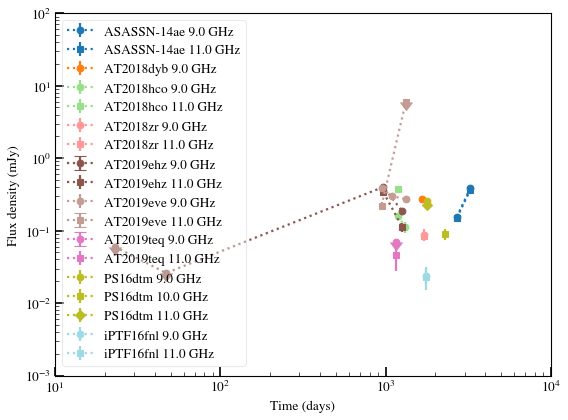

In [14]:
fig,ax = plt.subplots(figsize=(8, 6))
colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_events.keys())))
for event,color in zip(dict_events.keys(), colors_array):
    # if event != 'ASASSN-14ae':
    #     continue
    
    # print(len(np.unique(dict_events[event]['freq (GHz)'])))
    marker_array = ['o','s','D', '*','^','<','>','p','h','8']
    marker_num =0
    for freq in np.unique(dict_events[event]['freq (GHz)']):
        if np.abs(freq-10) > 1:
            continue
        freq_array = np.array([],dtype=int)
        uplims_array = np.array([],dtype=bool)
        for i in range(len(dict_events[event]['freq (GHz)'])):
            if dict_events[event]['freq (GHz)'][i] == freq:
                freq_array = np.append(freq_array,i)
                if dict_events[event]['error (mJy)'][i] == 0:
                    uplims_array = np.append(uplims_array,True)
                else:
                    uplims_array = np.append(uplims_array,False)
        ax.errorbar(dict_events[event]['times (d)'][freq_array], dict_events[event]['flux density (mJy)'][freq_array], 
                    yerr=dict_events[event]['error (mJy)'][freq_array], fmt=marker_array[marker_num], uplims=uplims_array,  
                    ms=6, color=color, label=f'{event} {freq} GHz',linestyle=':')
        marker_num+=1
ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(10,1e4)
ax.set_ylim(1e-3,1e2)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Flux density (mJy)')
plt.legend()

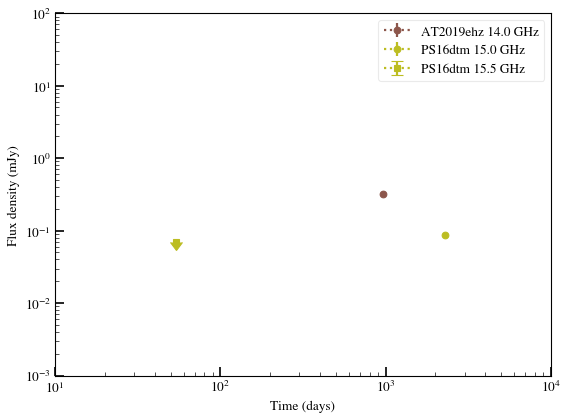

In [15]:
fig,ax = plt.subplots(figsize=(8, 6))
colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_events.keys())))
for event,color in zip(dict_events.keys(), colors_array):
    # if event != 'ASASSN-14ae':
    #     continue
    
    marker_array = ['o','s','D', '*','^','<','>','p','h','8']
    marker_num =0
    for freq in np.unique(dict_events[event]['freq (GHz)']):
        if np.abs(freq-15) > 1:
            continue
        freq_array = np.array([],dtype=int)
        uplims_array = np.array([],dtype=bool)
        for i in range(len(dict_events[event]['freq (GHz)'])):
            if dict_events[event]['freq (GHz)'][i] == freq:
                freq_array = np.append(freq_array,i)
                if dict_events[event]['error (mJy)'][i] == 0:
                    uplims_array = np.append(uplims_array,True)
                else:
                    uplims_array = np.append(uplims_array,False)
        ax.errorbar(dict_events[event]['times (d)'][freq_array], dict_events[event]['flux density (mJy)'][freq_array], 
                    yerr=dict_events[event]['error (mJy)'][freq_array], fmt=marker_array[marker_num], uplims=uplims_array,  
                    ms=6, color=color, label=f'{event} {freq} GHz',linestyle=':')
        marker_num+=1
ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(10,1e4)
ax.set_ylim(1e-3,1e2)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Flux density (mJy)')
plt.legend()

Lnu (erg/s/Hz)

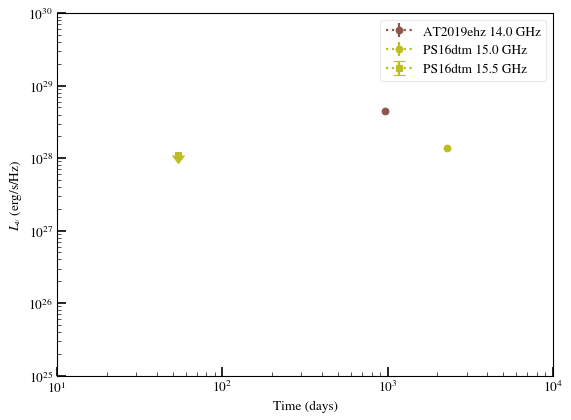

In [16]:
fig,ax = plt.subplots(figsize=(8, 6))
colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_events.keys())))
for event,color in zip(dict_events.keys(), colors_array):
    # if event != 'ASASSN-14ae':
    #     continue
    marker_array = ['o','s','D', '*','^','<','>','p','h','8']
    marker_num =0
    for freq in np.unique(dict_events[event]['freq (GHz)']):
        if np.abs(freq-15) > 1:
            continue

        freq_array = np.array([],dtype=int)
        uplims_array = np.array([],dtype=bool)
        for i in range(len(dict_events[event]['freq (GHz)'])):
            if dict_events[event]['freq (GHz)'][i] == freq:
                # print(i)
                freq_array = np.append(freq_array,i)
                if dict_events[event]['error (mJy)'][i] == 0:
                    uplims_array = np.append(uplims_array,True)
                else:
                    uplims_array = np.append(uplims_array,False)
                    
        ax.errorbar(dict_events[event]['times (d)'][freq_array], dict_events[event]['Lnu (erg/s/Hz)'][freq_array], 
                    yerr=dict_events[event]['error (erg/s/Hz)'][freq_array], fmt=marker_array[marker_num], uplims=uplims_array,  
                    ms=6, color=color, label=f'{event} {freq} GHz',linestyle=':')
        marker_num+=1
ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(10,1e4)
ax.set_ylim(1e25,1e30)
ax.set_xlabel('Time (days)')
ax.set_ylabel(r'$L_{\nu}$ (erg/s/Hz)')
plt.legend()

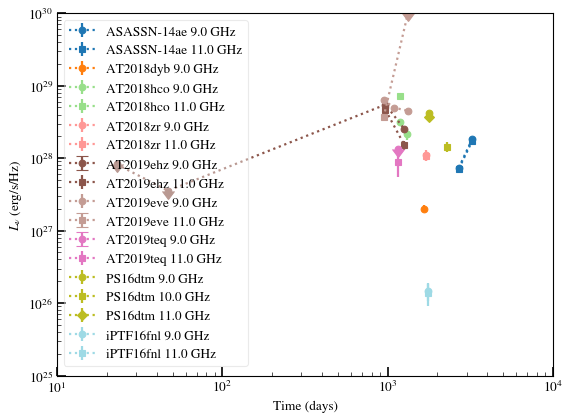

In [17]:
fig,ax = plt.subplots(figsize=(8, 6))
colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_events.keys())))
for event,color in zip(dict_events.keys(), colors_array):
    # if event != 'ASASSN-14ae':
    #     continue
    
    marker_array = ['o','s','D', '*','^','<','>','p','h','8']
    marker_num =0
    for freq in np.unique(dict_events[event]['freq (GHz)']):

        if np.abs(freq-10) > 1:
            continue

        freq_array = np.array([],dtype=int)
        uplims_array = np.array([],dtype=bool)
        for i in range(len(dict_events[event]['freq (GHz)'])):
            if dict_events[event]['freq (GHz)'][i] == freq:
                # print(i)
                freq_array = np.append(freq_array,i)
                if dict_events[event]['error (mJy)'][i] == 0:
                    uplims_array = np.append(uplims_array,True)
                else:
                    uplims_array = np.append(uplims_array,False)
                    
        ax.errorbar(dict_events[event]['times (d)'][freq_array], dict_events[event]['Lnu (erg/s/Hz)'][freq_array], 
                    yerr=dict_events[event]['error (erg/s/Hz)'][freq_array], fmt=marker_array[marker_num], uplims=uplims_array,  
                    ms=6, color=color, label=f'{event} {freq} GHz',linestyle=':')
        marker_num+=1
ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(10,1e4)
ax.set_ylim(1e25,1e30)
ax.set_xlabel('Time (days)')
ax.set_ylabel(r'$L_{\nu}$ (erg/s/Hz)')
plt.legend()

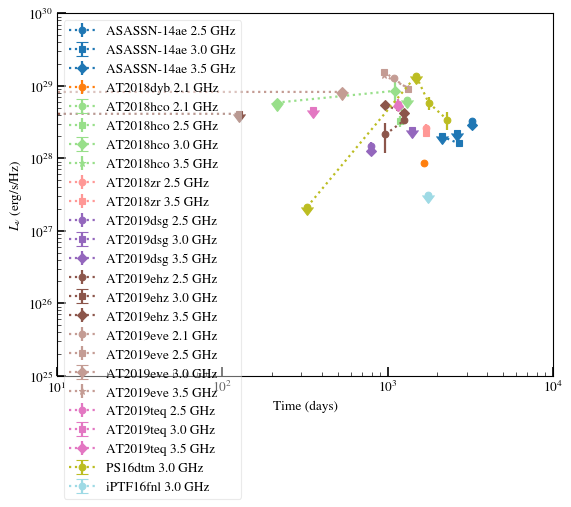

In [18]:
fig,ax = plt.subplots(figsize=(8, 6))
colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_events.keys())))
for event,color in zip(dict_events.keys(), colors_array):
    # if event != 'ASASSN-14ae':
    #     continue
    marker_array = ['o','s','D', '*','^','<','>','p','h','8']
    marker_num =0
    for freq in np.unique(dict_events[event]['freq (GHz)']):
        if np.abs(freq-3) > 1:
            continue
        freq_array = np.array([],dtype=int)
        uplims_array = np.array([],dtype=bool)
        for i in range(len(dict_events[event]['freq (GHz)'])):
            if dict_events[event]['freq (GHz)'][i] == freq:
                # print(i)
                freq_array = np.append(freq_array,i)
                if dict_events[event]['error (mJy)'][i] == 0:
                    uplims_array = np.append(uplims_array,True)
                else:
                    uplims_array = np.append(uplims_array,False)
                    
        ax.errorbar(dict_events[event]['times (d)'][freq_array], dict_events[event]['Lnu (erg/s/Hz)'][freq_array], 
                    yerr=dict_events[event]['error (erg/s/Hz)'][freq_array], fmt=marker_array[marker_num], uplims=uplims_array,  
                    ms=6, color=color, label=f'{event} {freq} GHz',linestyle=':')
        marker_num+=1
ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(10,1e4)
ax.set_ylim(1e25,1e30)
ax.set_xlabel('Time (days)')
ax.set_ylabel(r'$L_{\nu}$ (erg/s/Hz)')
plt.legend()

### $\nu L_\nu$ (erg/s) 

- this is only approximate. Cendes (2024) likely integrate the SED.

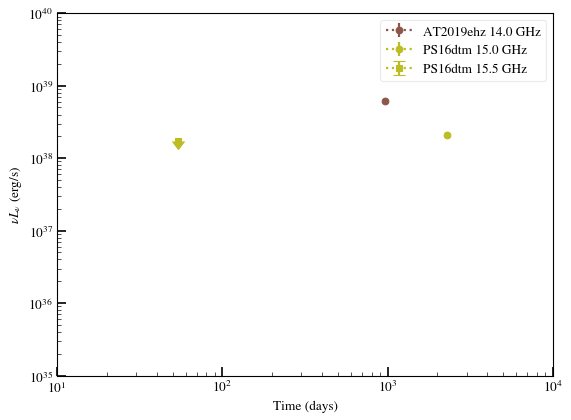

In [19]:
fig,ax = plt.subplots(figsize=(8, 6))
colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_events.keys())))
for event,color in zip(dict_events.keys(), colors_array):
    # if event != 'ASASSN-14ae':
    #     continue
    marker_array = ['o','s','D', '*','^','<','>','p','h','8']
    marker_num =0
    for freq in np.unique(dict_events[event]['freq (GHz)']):
        if np.abs(freq-15) > 1:
            continue

        freq_array = np.array([],dtype=int)
        uplims_array = np.array([],dtype=bool)
        for i in range(len(dict_events[event]['freq (GHz)'])):
            if dict_events[event]['freq (GHz)'][i] == freq:
                # print(i)
                freq_array = np.append(freq_array,i)
                if dict_events[event]['error (mJy)'][i] == 0:
                    uplims_array = np.append(uplims_array,True)
                else:
                    uplims_array = np.append(uplims_array,False)
                    
        ax.errorbar(dict_events[event]['times (d)'][freq_array], freq*1e9*dict_events[event]['Lnu (erg/s/Hz)'][freq_array], 
                    yerr=freq*1e9*dict_events[event]['error (erg/s/Hz)'][freq_array], fmt=marker_array[marker_num], uplims=uplims_array,  
                    ms=6, color=color, label=f'{event} {freq} GHz',linestyle=':')
        marker_num+=1
ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(10,1e4)
ax.set_ylim(1e35,1e40)
ax.set_xlabel('Time (days)')
ax.set_ylabel(r'$\nu L_{\nu}$ (erg/s)')
plt.legend()

ASASSN-14ae [6.67783842e+37 1.64576405e+38]
ASASSN-14ae [7.89851856e+37 1.90091013e+38]
AT2018dyb [1.81493955e+37]
AT2018hco [2.83030229e+38 1.95132643e+38]
AT2018hco [7.97133448e+38]
AT2018zr [9.88853451e+37]
AT2018zr [1.16739644e+38]
AT2019ehz [7.38293199e+37 3.19927053e+37 4.93425955e+38 2.26409914e+38]
AT2019ehz [5.08328540e+38 1.66936296e+38]
AT2019eve [5.73840011e+38 4.47148061e+38 4.05414242e+38]
AT2019eve [4.04420579e+38 1.09302859e+40]
AT2019teq [1.2129867e+38]
AT2019teq [9.88359531e+37]
PS16dtm [3.73404734e+38]
PS16dtm [1.44240544e+38]
PS16dtm [4.06466611e+38]
iPTF16fnl [1.30308323e+36]
iPTF16fnl [1.52629656e+36]


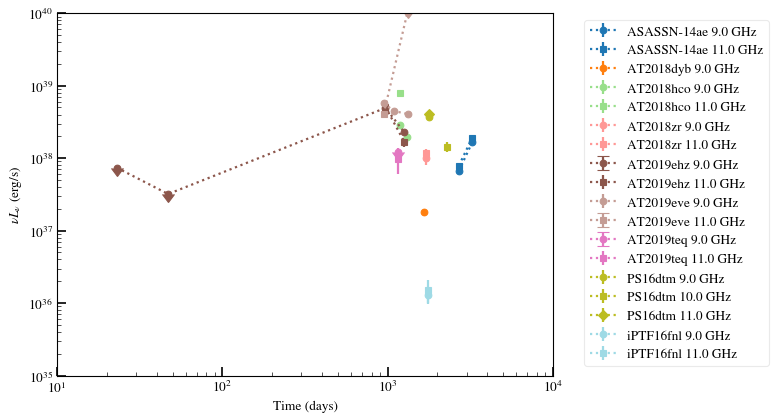

In [20]:
fig,ax = plt.subplots(figsize=(8, 6))
colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_events.keys())))
for event,color in zip(dict_events.keys(), colors_array):
    # if event != 'ASASSN-14ae':
    #     continue
    marker_array = ['o','s','D', '*','^','<','>','p','h','8']
    marker_num =0
    for freq in np.unique(dict_events[event]['freq (GHz)']):
        if np.abs(freq-10) > 1:
            continue

        freq_array = np.array([],dtype=int)
        uplims_array = np.array([],dtype=bool)
        for i in range(len(dict_events[event]['freq (GHz)'])):
            if dict_events[event]['freq (GHz)'][i] == freq:
                freq_array = np.append(freq_array,i)
                if dict_events[event]['error (mJy)'][i] == 0:
                    uplims_array = np.append(uplims_array,True)
                else:
                    uplims_array = np.append(uplims_array,False)
        print(event, freq*1e9*dict_events[event]['Lnu (erg/s/Hz)'][freq_array])
        ax.errorbar(dict_events[event]['times (d)'][freq_array], freq*1e9*dict_events[event]['Lnu (erg/s/Hz)'][freq_array], 
                    yerr=freq*1e9*dict_events[event]['error (erg/s/Hz)'][freq_array], fmt=marker_array[marker_num], uplims=uplims_array,  
                    ms=6, color=color, label=f'{event} {freq} GHz',linestyle=':')
        marker_num+=1
ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(10,1e4)
ax.set_ylim(1e35,1e40)
ax.set_xlabel('Time (days)')
ax.set_ylabel(r'$\nu L_{\nu}$ (erg/s)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Comparison to TDE Flare models

In [21]:
datadir_2flares_list = ['vmin_0p05c_vmax_0p4c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_deltat_0.3yr/',
                       'vmin_0p03c_vmax_0p3c/Mflare_1e-1/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_deltat_0.1yr',
                       'vmin_0p03c_vmax_0p3c/Mflare_1e-1/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_deltat_0.3yr',
                       'vmin_0p03c_vmax_0p3c/Mflare_1e-1/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_deltat_1yr',
                       'vmin_0p03c_vmax_0p3c/Mflare_1e-2/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_deltat_0.1yr',
                       'vmin_0p03c_vmax_0p3c/Mflare_1e-2/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_deltat_0.3yr',
                       'vmin_0p03c_vmax_0p3c/Mflare_1e-2/spectrum_evolution/evolve_spectrum_epsB_1e-1_p2p1/shell_evolution_deltat_0.1yr',
                       'vmin_0p03c_vmax_0p3c/Mflare_1e-2/spectrum_evolution/evolve_spectrum_epsB_1e-1_p2p1/shell_evolution_deltat_0.3yr',
                       'vmin_0p01c_vmax_0p1c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_deltat_0.1yr',
                       'vmin_0p01c_vmax_0p1c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_deltat_0.3yr',
                       'vmin_0p01c_vmax_0p1c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_deltat_1yr']
names_2flares_list = [r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm min} = 0.05c$, $v_{\rm max} = 0.4c$, $\Delta t=0.3$yr',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm min} = 0.03c$, $v_{\rm max} = 0.3c$, $\Delta t=0.1$yr',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm min} = 0.03c$, $v_{\rm max} = 0.3c$, $\Delta t=0.3$yr',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm min} = 0.03c$, $v_{\rm max} = 0.3c$, $\Delta t=1$yr',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm min} = 0.03c$, $v_{\rm max} = 0.3c$, $\Delta t=0.1$yr',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm min} = 0.03c$, $v_{\rm max} = 0.3c$, $\Delta t=0.3$yr',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm min} = 0.03c$, $v_{\rm max} = 0.3c$, $\Delta t=0.1$yr, $p=2.1$',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm min} = 0.03c$, $v_{\rm max} = 0.3c$, $\Delta t=0.3$yr, $p=2.1$',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm min} = 0.01c$, $v_{\rm max} = 0.1c$, $\Delta t=0.1$yr',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm min} = 0.01c$, $v_{\rm max} = 0.1c$, $\Delta t=0.3$yr',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm min} = 0.01c$, $v_{\rm max} = 0.1c$, $\Delta t=1$yr']

In [22]:
datadir_constism_list = ['constant_density_evol/Mflare_1e-1_vmax_0p1c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_10e-24_cgs',
                         'constant_density_evol/Mflare_1e-1_vmax_0p1c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_100e-24_cgs', 
                         'constant_density_evol/Mflare_1e-1_vmax_0p1c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_1000e-24_cgs',
                         'constant_density_evol/Mflare_1e-1_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_10e-24_cgs',
                         'constant_density_evol/Mflare_1e-1_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_100e-24_cgs',
                         'constant_density_evol/Mflare_1e-1_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_1000e-24_cgs',
                         'constant_density_evol/Mflare_1e-2_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_10e-24_cgs',
                         'constant_density_evol/Mflare_1e-2_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_100e-24_cgs',
                         'constant_density_evol/Mflare_1e-2_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_1000e-24_cgs']

names_constism_list = [r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.1c$, $\rho_{\rm ISM} = 10 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.1c$, $\rho_{\rm ISM} = 100 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.1c$, $\rho_{\rm ISM} = 1000 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 10 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 100 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 1000 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 10 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 100 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 1000 \times 10^{-24} \mathrm{g/cm^3}$']

Text(0.5, 1.0, '15 GHz')

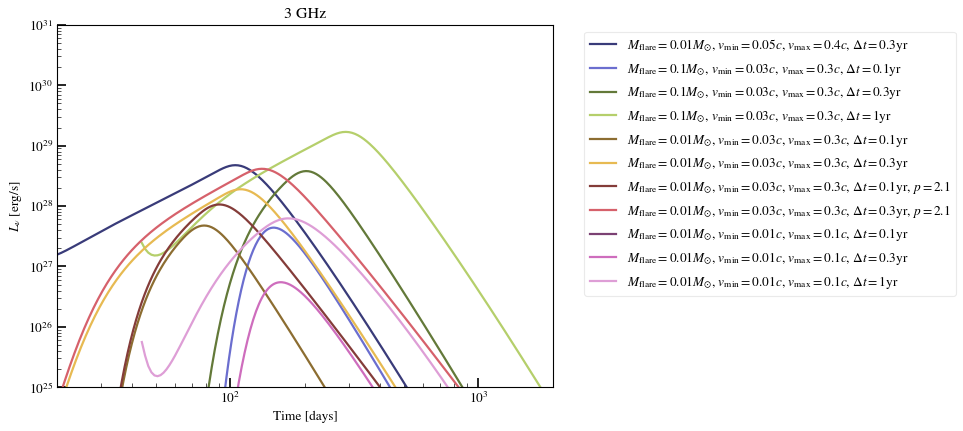

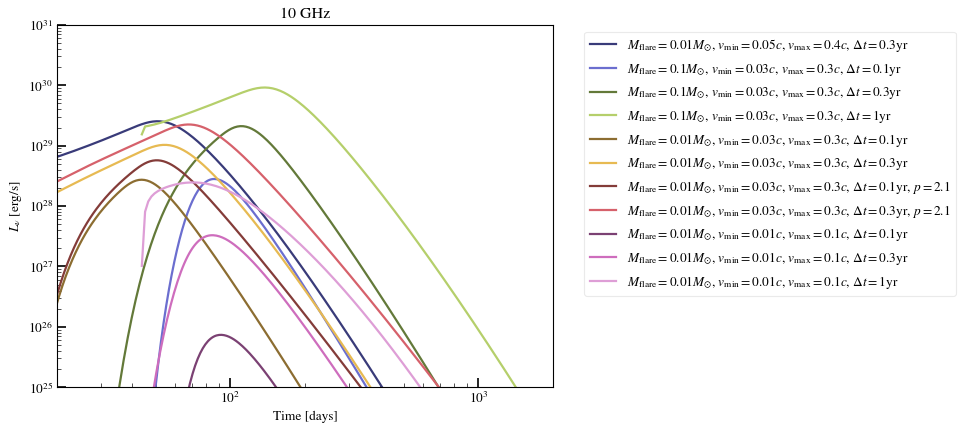

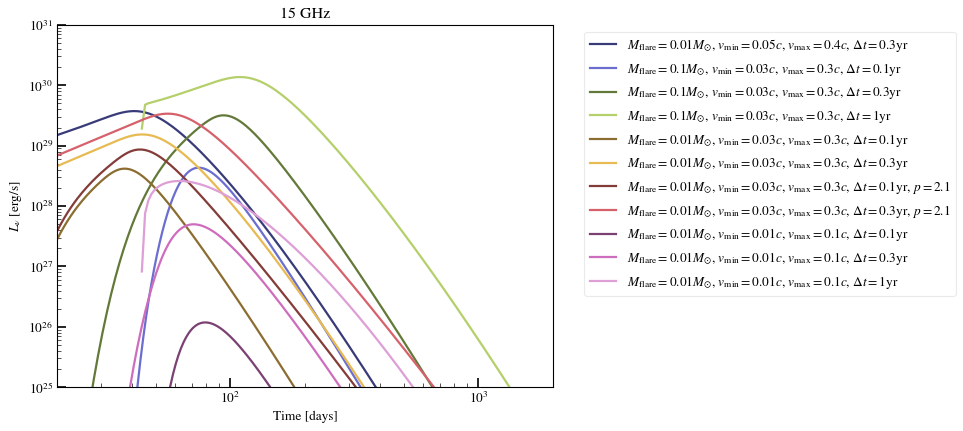

In [23]:
fig1,ax1 = plt.subplots()
fig2,ax2 = plt.subplots()
fig3,ax3 = plt.subplots()

colors_array = plt.cm.tab20b(np.linspace(0, 1, len(datadir_2flares_list)))

for i,datadir in enumerate(datadir_2flares_list):

    flare1_dict = {}
    flare2_dict = {}

    flare1_dict['Lnu_3GHz'] = np.load(datadir+'/flare1/'+'Lnu_3.00GHz_sparse_Te_1.0E+04.npz')
    flare2_dict['Lnu_3GHz'] = np.load(datadir+'/flare2/'+'Lnu_3.00GHz_sparse_Te_1.0E+04.npz')

    flare1_dict['Lnu_10GHz'] = np.load(datadir+'/flare1/'+'Lnu_10.00GHz_sparse_Te_1.0E+04.npz')
    flare2_dict['Lnu_10GHz'] = np.load(datadir+'/flare2/'+'Lnu_10.00GHz_sparse_Te_1.0E+04.npz')

    flare1_dict['Lnu_15GHz'] = np.load(datadir+'/flare1/'+'Lnu_15.00GHz_sparse_Te_1.0E+04.npz')
    flare2_dict['Lnu_15GHz'] = np.load(datadir+'/flare2/'+'Lnu_15.00GHz_sparse_Te_1.0E+04.npz')

    ax1.plot(flare1_dict['Lnu_3GHz']['times_yr']*365.25,(flare1_dict['Lnu_3GHz']['Lnu_abs_atfreq']+flare2_dict['Lnu_3GHz']['Lnu_abs_atfreq']),color=colors_array[i],label=names_2flares_list[i])
    ax2.plot(flare1_dict['Lnu_10GHz']['times_yr']*365.25,(flare1_dict['Lnu_10GHz']['Lnu_abs_atfreq']+flare2_dict['Lnu_10GHz']['Lnu_abs_atfreq']),color=colors_array[i],label=names_2flares_list[i])
    ax3.plot(flare1_dict['Lnu_15GHz']['times_yr']*365.25,(flare1_dict['Lnu_15GHz']['Lnu_abs_atfreq']+flare2_dict['Lnu_15GHz']['Lnu_abs_atfreq']),color=colors_array[i],label=names_2flares_list[i])

for ax in [ax1,ax2,ax3]:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Time [days]')
    ax.set_ylabel(r'$L_{\nu}$ [erg/s]')
    ax.set_ylim(1e25,1e31)
    ax.set_xlim(20,2e3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.set_title('3 GHz')
ax2.set_title('10 GHz')
ax3.set_title('15 GHz')

Text(0.5, 1.0, '15 GHz')

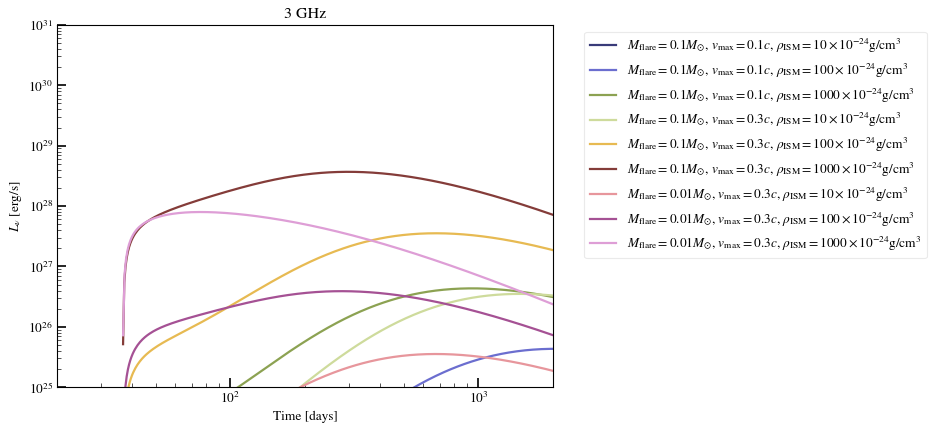

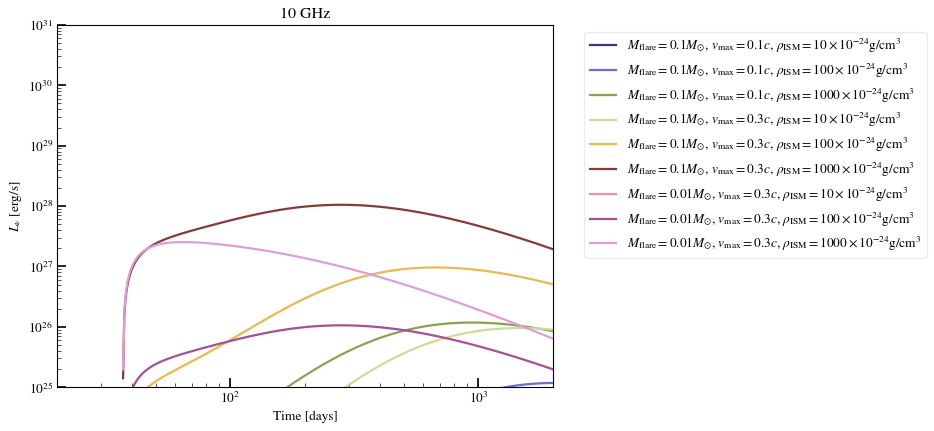

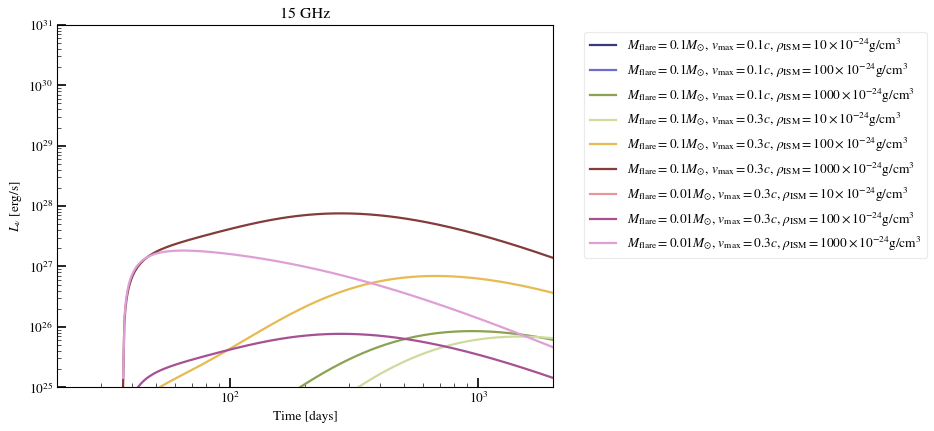

In [24]:
fig1,ax1 = plt.subplots()
fig2,ax2 = plt.subplots()
fig3,ax3 = plt.subplots()

colors_array = plt.cm.tab20b(np.linspace(0, 1, len(datadir_constism_list)))

for i,datadir in enumerate(datadir_constism_list):

    flare2_dict = {}

    flare2_dict['Lnu_3GHz'] = np.load(datadir+'/flare2/'+'Lnu_3.00GHz_sparse_Te_1.0E+04.npz')

    flare2_dict['Lnu_10GHz'] = np.load(datadir+'/flare2/'+'Lnu_10.00GHz_sparse_Te_1.0E+04.npz')

    flare2_dict['Lnu_15GHz'] = np.load(datadir+'/flare2/'+'Lnu_15.00GHz_sparse_Te_1.0E+04.npz')

    ax1.plot(flare2_dict['Lnu_3GHz']['times_yr']*365.25,(flare2_dict['Lnu_3GHz']['Lnu_abs_atfreq']),color=colors_array[i],label=names_constism_list[i])
    ax2.plot(flare2_dict['Lnu_10GHz']['times_yr']*365.25,(flare2_dict['Lnu_10GHz']['Lnu_abs_atfreq']),color=colors_array[i],label=names_constism_list[i])
    ax3.plot(flare2_dict['Lnu_15GHz']['times_yr']*365.25,(flare2_dict['Lnu_15GHz']['Lnu_abs_atfreq']),color=colors_array[i],label=names_constism_list[i])

for ax in [ax1,ax2,ax3]:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Time [days]')
    ax.set_ylabel(r'$L_{\nu}$ [erg/s]')
    ax.set_ylim(1e25,1e31)
    ax.set_xlim(20,2e3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.set_title('3 GHz')
ax2.set_title('10 GHz')
ax3.set_title('15 GHz')

## above plotted alone, here plotted with data

### 15 GHz

Text(0.5, 1.0, '2 Flare models')

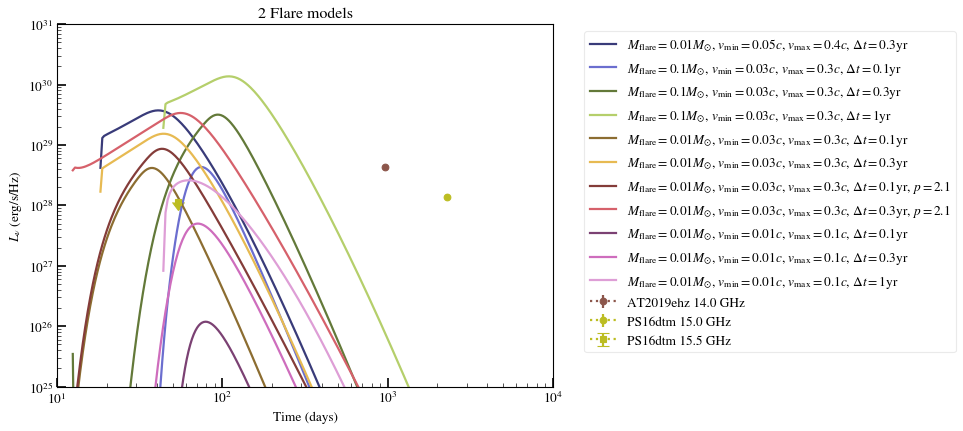

In [25]:
fig,ax = plt.subplots(figsize=(8, 6))
colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_events.keys())))
for event,color in zip(dict_events.keys(), colors_array):
    # if event != 'ASASSN-14ae':
    #     continue
    
    # print(len(np.unique(dict_events[event]['freq (GHz)'])))
    marker_array = ['o','s','D', '*','^','<','>','p','h','8']
    marker_num =0
    for freq in np.unique(dict_events[event]['freq (GHz)']):
        if np.abs(freq-15) > 1:
            continue

        freq_array = np.array([],dtype=int)
        uplims_array = np.array([],dtype=bool)
        for i in range(len(dict_events[event]['freq (GHz)'])):
            if dict_events[event]['freq (GHz)'][i] == freq:
                # print(i)
                freq_array = np.append(freq_array,i)
                if dict_events[event]['error (mJy)'][i] == 0:
                    uplims_array = np.append(uplims_array,True)
                else:
                    uplims_array = np.append(uplims_array,False)
                    
        ax.errorbar(dict_events[event]['times (d)'][freq_array], dict_events[event]['Lnu (erg/s/Hz)'][freq_array], 
                    yerr=dict_events[event]['error (erg/s/Hz)'][freq_array], fmt=marker_array[marker_num], uplims=uplims_array,  
                    ms=6, color=color, label=f'{event} {freq} GHz',linestyle=':')

        marker_num+=1
        


colors_array = plt.cm.tab20b(np.linspace(0, 1, len(datadir_2flares_list)))

for i,datadir in enumerate(datadir_2flares_list):

    flare1_dict = {}
    flare2_dict = {}

    flare1_dict['Lnu_3GHz'] = np.load(datadir+'/flare1/'+'Lnu_3.00GHz_sparse_Te_1.0E+04.npz')
    flare2_dict['Lnu_3GHz'] = np.load(datadir+'/flare2/'+'Lnu_3.00GHz_sparse_Te_1.0E+04.npz')

    flare1_dict['Lnu_10GHz'] = np.load(datadir+'/flare1/'+'Lnu_10.00GHz_sparse_Te_1.0E+04.npz')
    flare2_dict['Lnu_10GHz'] = np.load(datadir+'/flare2/'+'Lnu_10.00GHz_sparse_Te_1.0E+04.npz')

    flare1_dict['Lnu_15GHz'] = np.load(datadir+'/flare1/'+'Lnu_15.00GHz_sparse_Te_1.0E+04.npz')
    flare2_dict['Lnu_15GHz'] = np.load(datadir+'/flare2/'+'Lnu_15.00GHz_sparse_Te_1.0E+04.npz')

    ax.plot(flare1_dict['Lnu_15GHz']['times_yr']*365.25,(flare1_dict['Lnu_15GHz']['Lnu_abs_atfreq']+flare2_dict['Lnu_15GHz']['Lnu_abs_atfreq']),color=colors_array[i],label=names_2flares_list[i])

ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(10,1e4)
ax.set_ylim(1e25,1e31)
ax.set_xlabel('Time (days)')
ax.set_ylabel(r'$L_{\nu}$ (erg/s/Hz)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('2 Flare models')

Text(0.5, 1.0, '2 Flare models (shifted)')

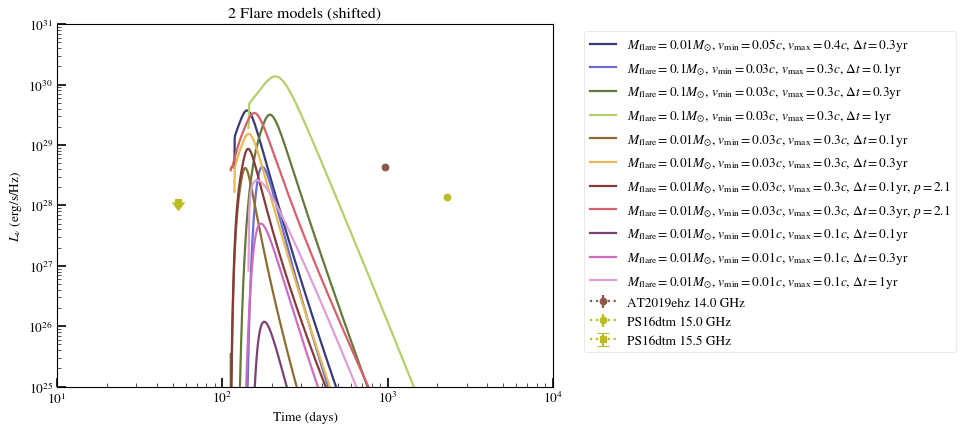

In [26]:
fig,ax = plt.subplots(figsize=(8, 6))
colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_events.keys())))
for event,color in zip(dict_events.keys(), colors_array):
    # if event != 'ASASSN-14ae':
    #     continue
    marker_array = ['o','s','D', '*','^','<','>','p','h','8']
    marker_num =0
    for freq in np.unique(dict_events[event]['freq (GHz)']):
        if np.abs(freq-15) > 1:
            continue

        freq_array = np.array([],dtype=int)
        uplims_array = np.array([],dtype=bool)
        for i in range(len(dict_events[event]['freq (GHz)'])):
            if dict_events[event]['freq (GHz)'][i] == freq:
                # print(i)
                freq_array = np.append(freq_array,i)
                if dict_events[event]['error (mJy)'][i] == 0:
                    uplims_array = np.append(uplims_array,True)
                else:
                    uplims_array = np.append(uplims_array,False)
                    
        ax.errorbar(dict_events[event]['times (d)'][freq_array], dict_events[event]['Lnu (erg/s/Hz)'][freq_array], 
                    yerr=dict_events[event]['error (erg/s/Hz)'][freq_array], fmt=marker_array[marker_num], uplims=uplims_array,  
                    ms=6, color=color, label=f'{event} {freq} GHz',linestyle=':')
        marker_num+=1
        


colors_array = plt.cm.tab20b(np.linspace(0, 1, len(datadir_2flares_list)))

for i,datadir in enumerate(datadir_2flares_list):

    flare1_dict = {}
    flare2_dict = {}

    flare1_dict['Lnu_3GHz'] = np.load(datadir+'/flare1/'+'Lnu_3.00GHz_sparse_Te_1.0E+04.npz')
    flare2_dict['Lnu_3GHz'] = np.load(datadir+'/flare2/'+'Lnu_3.00GHz_sparse_Te_1.0E+04.npz')

    flare1_dict['Lnu_10GHz'] = np.load(datadir+'/flare1/'+'Lnu_10.00GHz_sparse_Te_1.0E+04.npz')
    flare2_dict['Lnu_10GHz'] = np.load(datadir+'/flare2/'+'Lnu_10.00GHz_sparse_Te_1.0E+04.npz')

    flare1_dict['Lnu_15GHz'] = np.load(datadir+'/flare1/'+'Lnu_15.00GHz_sparse_Te_1.0E+04.npz')
    flare2_dict['Lnu_15GHz'] = np.load(datadir+'/flare2/'+'Lnu_15.00GHz_sparse_Te_1.0E+04.npz')

    ax.plot(flare1_dict['Lnu_15GHz']['times_yr']*365.25 + 100,(flare1_dict['Lnu_15GHz']['Lnu_abs_atfreq']+flare2_dict['Lnu_15GHz']['Lnu_abs_atfreq']),color=colors_array[i],label=names_2flares_list[i])

ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(10,1e4)
ax.set_ylim(1e25,1e31)
ax.set_xlabel('Time (days)')
ax.set_ylabel(r'$L_{\nu}$ (erg/s/Hz)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('2 Flare models (shifted)')

Text(0.5, 1.0, 'Constant density ISM models')

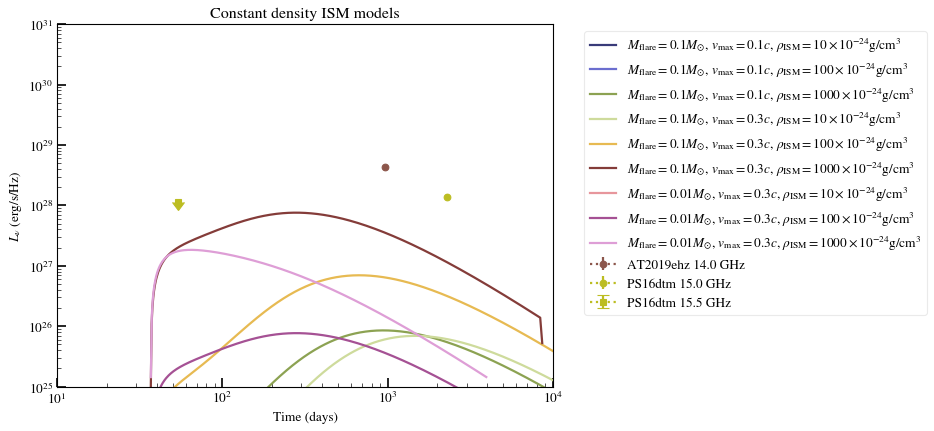

In [27]:
fig,ax = plt.subplots(figsize=(8, 6))
colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_events.keys())))
for event,color in zip(dict_events.keys(), colors_array):
    # if event != 'ASASSN-14ae':
    #     continue
    marker_array = ['o','s','D', '*','^','<','>','p','h','8']
    marker_num =0
    for freq in np.unique(dict_events[event]['freq (GHz)']):
        if np.abs(freq-15) > 1:
            continue

        freq_array = np.array([],dtype=int)
        uplims_array = np.array([],dtype=bool)
        for i in range(len(dict_events[event]['freq (GHz)'])):
            if dict_events[event]['freq (GHz)'][i] == freq:
                # print(i)
                freq_array = np.append(freq_array,i)
                if dict_events[event]['error (mJy)'][i] == 0:
                    uplims_array = np.append(uplims_array,True)
                else:
                    uplims_array = np.append(uplims_array,False)
                    
        ax.errorbar(dict_events[event]['times (d)'][freq_array], dict_events[event]['Lnu (erg/s/Hz)'][freq_array], 
                    yerr=dict_events[event]['error (erg/s/Hz)'][freq_array], fmt=marker_array[marker_num], uplims=uplims_array,  
                    ms=6, color=color, label=f'{event} {freq} GHz',linestyle=':')
        marker_num+=1
        

colors_array = plt.cm.tab20b(np.linspace(0, 1, len(datadir_constism_list)))

for i,datadir in enumerate(datadir_constism_list):

    flare2_dict = {}

    flare2_dict['Lnu_3GHz'] = np.load(datadir+'/flare2/'+'Lnu_3.00GHz_sparse_Te_1.0E+04.npz')

    flare2_dict['Lnu_10GHz'] = np.load(datadir+'/flare2/'+'Lnu_10.00GHz_sparse_Te_1.0E+04.npz')

    flare2_dict['Lnu_15GHz'] = np.load(datadir+'/flare2/'+'Lnu_15.00GHz_sparse_Te_1.0E+04.npz')

    ax.plot(flare2_dict['Lnu_15GHz']['times_yr']*365.25,(flare2_dict['Lnu_15GHz']['Lnu_abs_atfreq']),color=colors_array[i],label=names_constism_list[i])

ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(10,1e4)
ax.set_ylim(1e25,1e31)
ax.set_xlabel('Time (days)')
ax.set_ylabel(r'$L_{\nu}$ (erg/s/Hz)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Constant density ISM models')

### 10 GHz

Text(0.5, 1.0, '2 Flare models')

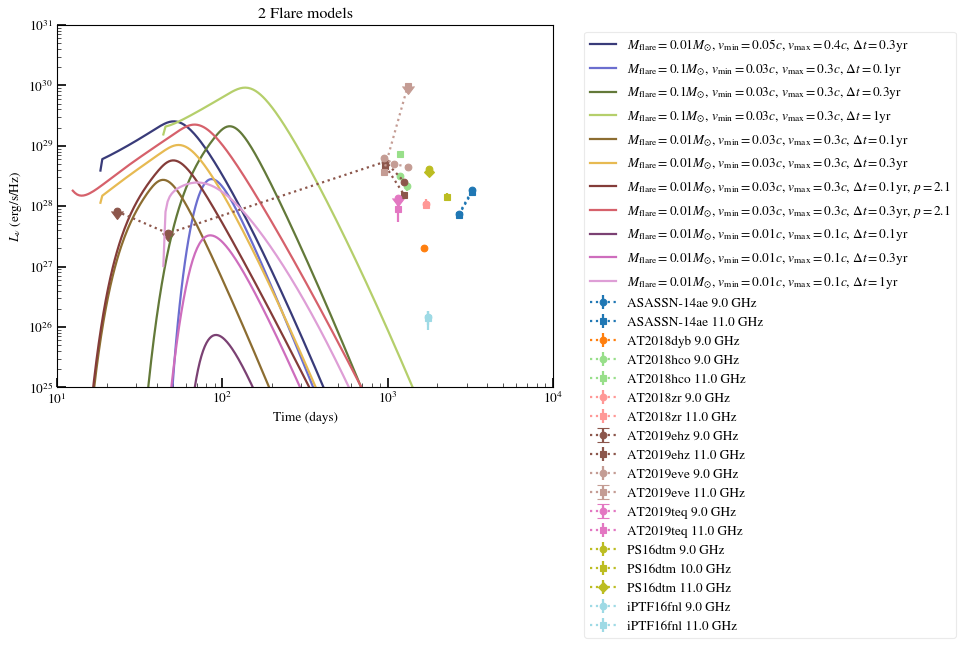

In [28]:
fig,ax = plt.subplots(figsize=(8, 6))
colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_events.keys())))
for event,color in zip(dict_events.keys(), colors_array):
    # if event != 'ASASSN-14ae':
    #     continue
    
    marker_array = ['o','s','D', '*','^','<','>','p','h','8']
    marker_num =0
    for freq in np.unique(dict_events[event]['freq (GHz)']):
        if np.abs(freq-10) > 1:
            continue

        freq_array = np.array([],dtype=int)
        uplims_array = np.array([],dtype=bool)
        for i in range(len(dict_events[event]['freq (GHz)'])):
            if dict_events[event]['freq (GHz)'][i] == freq:
                freq_array = np.append(freq_array,i)
                if dict_events[event]['error (mJy)'][i] == 0:
                    uplims_array = np.append(uplims_array,True)
                else:
                    uplims_array = np.append(uplims_array,False)
                    
        ax.errorbar(dict_events[event]['times (d)'][freq_array], dict_events[event]['Lnu (erg/s/Hz)'][freq_array], 
                    yerr=dict_events[event]['error (erg/s/Hz)'][freq_array], fmt=marker_array[marker_num], uplims=uplims_array,  
                    ms=6, color=color, label=f'{event} {freq} GHz',linestyle=':')
        marker_num+=1

colors_array = plt.cm.tab20b(np.linspace(0, 1, len(datadir_2flares_list)))

for i,datadir in enumerate(datadir_2flares_list):

    flare1_dict = {}
    flare2_dict = {}

    flare1_dict['Lnu_3GHz'] = np.load(datadir+'/flare1/'+'Lnu_3.00GHz_sparse_Te_1.0E+04.npz')
    flare2_dict['Lnu_3GHz'] = np.load(datadir+'/flare2/'+'Lnu_3.00GHz_sparse_Te_1.0E+04.npz')

    flare1_dict['Lnu_10GHz'] = np.load(datadir+'/flare1/'+'Lnu_10.00GHz_sparse_Te_1.0E+04.npz')
    flare2_dict['Lnu_10GHz'] = np.load(datadir+'/flare2/'+'Lnu_10.00GHz_sparse_Te_1.0E+04.npz')

    flare1_dict['Lnu_15GHz'] = np.load(datadir+'/flare1/'+'Lnu_15.00GHz_sparse_Te_1.0E+04.npz')
    flare2_dict['Lnu_15GHz'] = np.load(datadir+'/flare2/'+'Lnu_15.00GHz_sparse_Te_1.0E+04.npz')

    ax.plot(flare1_dict['Lnu_10GHz']['times_yr']*365.25,(flare1_dict['Lnu_10GHz']['Lnu_abs_atfreq']+flare2_dict['Lnu_10GHz']['Lnu_abs_atfreq']),color=colors_array[i],label=names_2flares_list[i])

ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(10,1e4)
ax.set_ylim(1e25,1e31)
ax.set_xlabel('Time (days)')
ax.set_ylabel(r'$L_{\nu}$ (erg/s/Hz)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('2 Flare models')

Text(0.5, 1.0, '2 Flare models (shifted)')

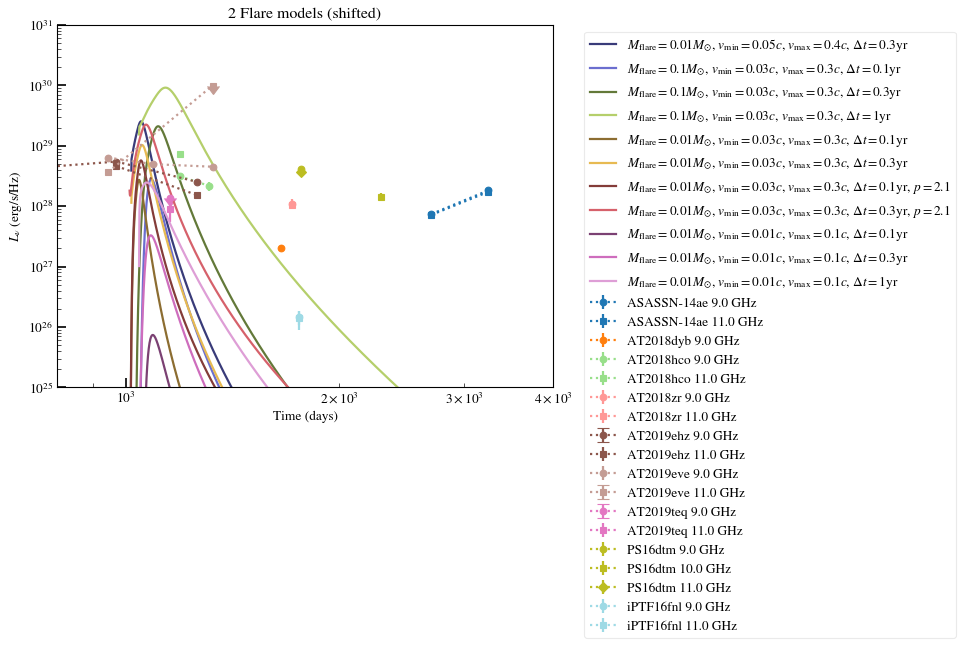

In [29]:
fig,ax = plt.subplots(figsize=(8, 6))
colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_events.keys())))
for event,color in zip(dict_events.keys(), colors_array):
    # if event != 'ASASSN-14ae':
    #     continue
    marker_array = ['o','s','D', '*','^','<','>','p','h','8']
    marker_num =0
    for freq in np.unique(dict_events[event]['freq (GHz)']):
        if np.abs(freq-10) > 1:
            continue

        freq_array = np.array([],dtype=int)
        uplims_array = np.array([],dtype=bool)
        for i in range(len(dict_events[event]['freq (GHz)'])):
            if dict_events[event]['freq (GHz)'][i] == freq:
                # print(i)
                freq_array = np.append(freq_array,i)
                if dict_events[event]['error (mJy)'][i] == 0:
                    uplims_array = np.append(uplims_array,True)
                else:
                    uplims_array = np.append(uplims_array,False)
                    
        ax.errorbar(dict_events[event]['times (d)'][freq_array], dict_events[event]['Lnu (erg/s/Hz)'][freq_array], 
                    yerr=dict_events[event]['error (erg/s/Hz)'][freq_array], fmt=marker_array[marker_num], uplims=uplims_array,  
                    ms=6, color=color, label=f'{event} {freq} GHz',linestyle=':')
        marker_num+=1
        


colors_array = plt.cm.tab20b(np.linspace(0, 1, len(datadir_2flares_list)))

for i,datadir in enumerate(datadir_2flares_list):

    flare1_dict = {}
    flare2_dict = {}

    flare1_dict['Lnu_3GHz'] = np.load(datadir+'/flare1/'+'Lnu_3.00GHz_sparse_Te_1.0E+04.npz')
    flare2_dict['Lnu_3GHz'] = np.load(datadir+'/flare2/'+'Lnu_3.00GHz_sparse_Te_1.0E+04.npz')

    flare1_dict['Lnu_10GHz'] = np.load(datadir+'/flare1/'+'Lnu_10.00GHz_sparse_Te_1.0E+04.npz')
    flare2_dict['Lnu_10GHz'] = np.load(datadir+'/flare2/'+'Lnu_10.00GHz_sparse_Te_1.0E+04.npz')

    flare1_dict['Lnu_15GHz'] = np.load(datadir+'/flare1/'+'Lnu_15.00GHz_sparse_Te_1.0E+04.npz')
    flare2_dict['Lnu_15GHz'] = np.load(datadir+'/flare2/'+'Lnu_15.00GHz_sparse_Te_1.0E+04.npz')

    ax.plot(flare1_dict['Lnu_10GHz']['times_yr']*365.25 + 1e3,(flare1_dict['Lnu_10GHz']['Lnu_abs_atfreq']+flare2_dict['Lnu_10GHz']['Lnu_abs_atfreq']),color=colors_array[i],label=names_2flares_list[i])

ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(8e2,4e3)
ax.set_ylim(1e25,1e31)
ax.set_xlabel('Time (days)')
ax.set_ylabel(r'$L_{\nu}$ (erg/s/Hz)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('2 Flare models (shifted)')

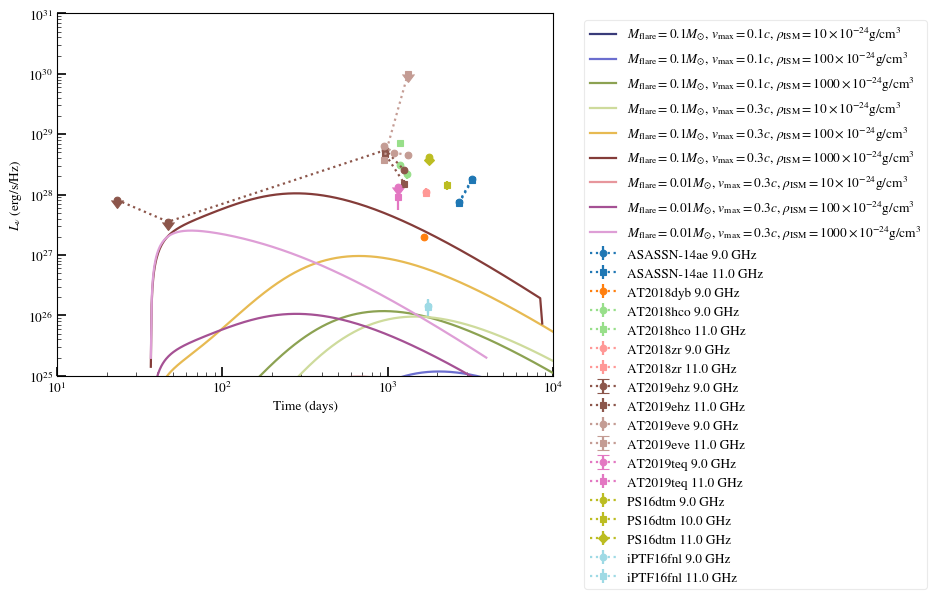

In [30]:
fig,ax = plt.subplots(figsize=(8, 6))
colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_events.keys())))
for event,color in zip(dict_events.keys(), colors_array):
    # if event != 'ASASSN-14ae':
    #     continue
    
    # print(len(np.unique(dict_events[event]['freq (GHz)'])))
    marker_array = ['o','s','D', '*','^','<','>','p','h','8']
    marker_num =0
    for freq in np.unique(dict_events[event]['freq (GHz)']):
        if np.abs(freq-10) > 1:
            continue
        freq_array = np.array([],dtype=int)
        uplims_array = np.array([],dtype=bool)
        for i in range(len(dict_events[event]['freq (GHz)'])):
            if dict_events[event]['freq (GHz)'][i] == freq:
                # print(i)
                freq_array = np.append(freq_array,i)
                if dict_events[event]['error (mJy)'][i] == 0:
                    uplims_array = np.append(uplims_array,True)
                else:
                    uplims_array = np.append(uplims_array,False)
                    
        ax.errorbar(dict_events[event]['times (d)'][freq_array], dict_events[event]['Lnu (erg/s/Hz)'][freq_array], 
                    yerr=dict_events[event]['error (erg/s/Hz)'][freq_array], fmt=marker_array[marker_num], uplims=uplims_array,  
                    ms=6, color=color, label=f'{event} {freq} GHz',linestyle=':')
        marker_num+=1


colors_array = plt.cm.tab20b(np.linspace(0, 1, len(datadir_constism_list)))

for i,datadir in enumerate(datadir_constism_list):

    flare2_dict = {}

    flare2_dict['Lnu_3GHz'] = np.load(datadir+'/flare2/'+'Lnu_3.00GHz_sparse_Te_1.0E+04.npz')

    flare2_dict['Lnu_10GHz'] = np.load(datadir+'/flare2/'+'Lnu_10.00GHz_sparse_Te_1.0E+04.npz')

    flare2_dict['Lnu_15GHz'] = np.load(datadir+'/flare2/'+'Lnu_15.00GHz_sparse_Te_1.0E+04.npz')

    ax.plot(flare2_dict['Lnu_10GHz']['times_yr']*365.25,(flare2_dict['Lnu_10GHz']['Lnu_abs_atfreq']),color=colors_array[i],label=names_constism_list[i])

ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(10,1e4)
ax.set_ylim(1e25,1e31)
ax.set_xlabel('Time (days)')
ax.set_ylabel(r'$L_{\nu}$ (erg/s/Hz)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

### 3 GHz

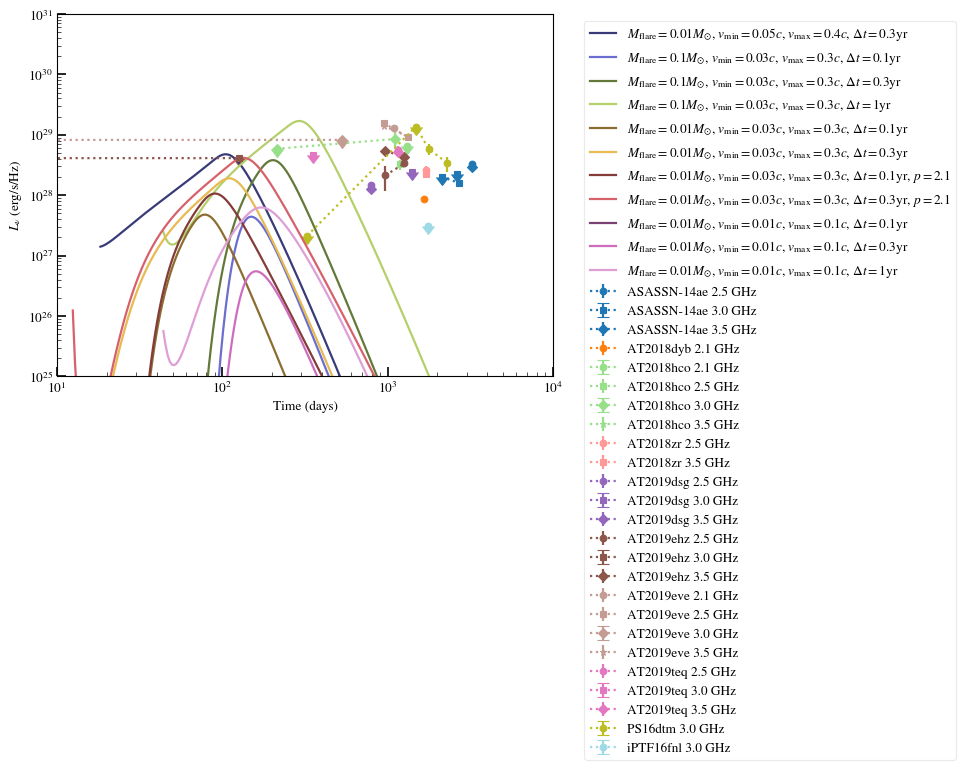

In [34]:
fig,ax = plt.subplots(figsize=(8, 6))
colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_events.keys())))
for event,color in zip(dict_events.keys(), colors_array):
    # if event != 'ASASSN-14ae':
    #     continue
    
    # print(len(np.unique(dict_events[event]['freq (GHz)'])))
    marker_array = ['o','s','D', '*','^','<','>','p','h','8']
    marker_num =0
    for freq in np.unique(dict_events[event]['freq (GHz)']):
        if np.abs(freq-3) > 1:
            continue

        freq_array = np.array([],dtype=int)
        uplims_array = np.array([],dtype=bool)
        for i in range(len(dict_events[event]['freq (GHz)'])):
            if dict_events[event]['freq (GHz)'][i] == freq:
                # print(i)
                freq_array = np.append(freq_array,i)
                if dict_events[event]['error (mJy)'][i] == 0:
                    uplims_array = np.append(uplims_array,True)
                else:
                    uplims_array = np.append(uplims_array,False)
                    
        ax.errorbar(dict_events[event]['times (d)'][freq_array], dict_events[event]['Lnu (erg/s/Hz)'][freq_array], 
                    yerr=dict_events[event]['error (erg/s/Hz)'][freq_array], fmt=marker_array[marker_num], uplims=uplims_array,  
                    ms=6, color=color, label=f'{event} {freq} GHz',linestyle=':')
        marker_num+=1
        


colors_array = plt.cm.tab20b(np.linspace(0, 1, len(datadir_2flares_list)))

for i,datadir in enumerate(datadir_2flares_list):

    flare1_dict = {}
    flare2_dict = {}

    flare1_dict['Lnu_3GHz'] = np.load(datadir+'/flare1/'+'Lnu_3.00GHz_sparse_Te_1.0E+04.npz')
    flare2_dict['Lnu_3GHz'] = np.load(datadir+'/flare2/'+'Lnu_3.00GHz_sparse_Te_1.0E+04.npz')

    flare1_dict['Lnu_10GHz'] = np.load(datadir+'/flare1/'+'Lnu_10.00GHz_sparse_Te_1.0E+04.npz')
    flare2_dict['Lnu_10GHz'] = np.load(datadir+'/flare2/'+'Lnu_10.00GHz_sparse_Te_1.0E+04.npz')

    flare1_dict['Lnu_15GHz'] = np.load(datadir+'/flare1/'+'Lnu_15.00GHz_sparse_Te_1.0E+04.npz')
    flare2_dict['Lnu_15GHz'] = np.load(datadir+'/flare2/'+'Lnu_15.00GHz_sparse_Te_1.0E+04.npz')

    ax.plot(flare1_dict['Lnu_3GHz']['times_yr']*365.25,(flare1_dict['Lnu_3GHz']['Lnu_abs_atfreq']+flare2_dict['Lnu_3GHz']['Lnu_abs_atfreq']),color=colors_array[i],label=names_2flares_list[i])

ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(10,1e4)
ax.set_ylim(1e25,1e31)
ax.set_xlabel('Time (days)')
ax.set_ylabel(r'$L_{\nu}$ (erg/s/Hz)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

Text(0.5, 1.0, '2 Flare models (shifted)')

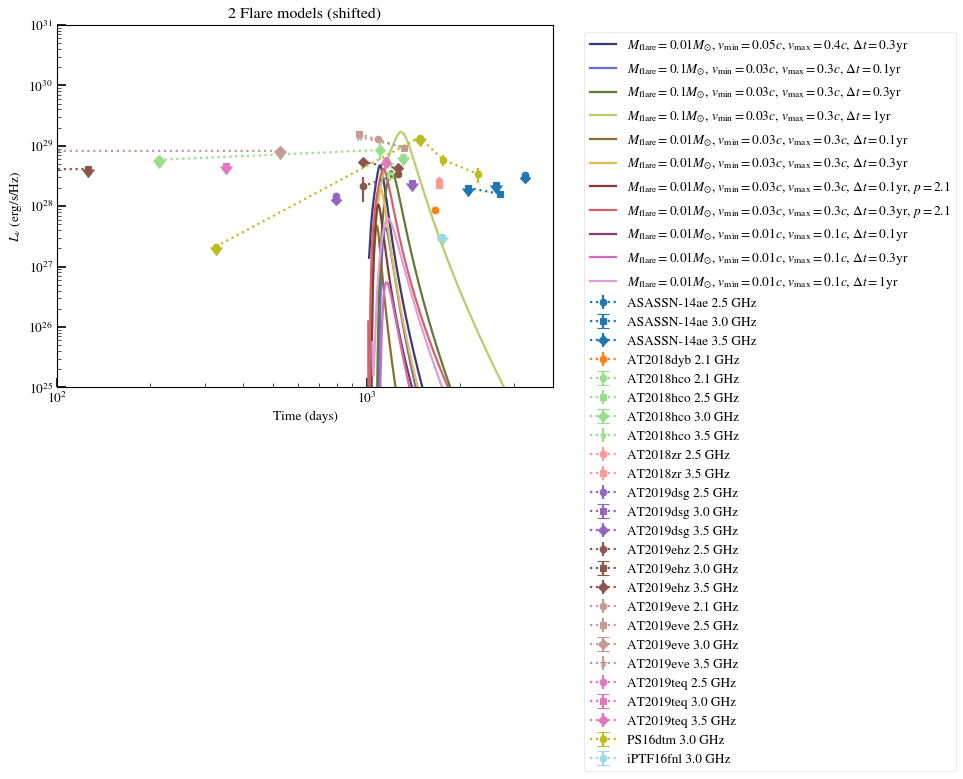

In [37]:
fig,ax = plt.subplots(figsize=(8, 6))
colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_events.keys())))
for event,color in zip(dict_events.keys(), colors_array):
    # if event != 'ASASSN-14ae':
    #     continue
    
    # print(len(np.unique(dict_events[event]['freq (GHz)'])))
    marker_array = ['o','s','D', '*','^','<','>','p','h','8']
    marker_num =0
    for freq in np.unique(dict_events[event]['freq (GHz)']):
        if np.abs(freq-3) > 1:
            continue

        freq_array = np.array([],dtype=int)
        uplims_array = np.array([],dtype=bool)
        for i in range(len(dict_events[event]['freq (GHz)'])):
            if dict_events[event]['freq (GHz)'][i] == freq:
                # print(i)
                freq_array = np.append(freq_array,i)
                if dict_events[event]['error (mJy)'][i] == 0:
                    uplims_array = np.append(uplims_array,True)
                else:
                    uplims_array = np.append(uplims_array,False)
                    
        ax.errorbar(dict_events[event]['times (d)'][freq_array], dict_events[event]['Lnu (erg/s/Hz)'][freq_array], 
                    yerr=dict_events[event]['error (erg/s/Hz)'][freq_array], fmt=marker_array[marker_num], uplims=uplims_array,  
                    ms=6, color=color, label=f'{event} {freq} GHz',linestyle=':')

        marker_num+=1
        


colors_array = plt.cm.tab20b(np.linspace(0, 1, len(datadir_2flares_list)))

for i,datadir in enumerate(datadir_2flares_list):

    flare1_dict = {}
    flare2_dict = {}

    flare1_dict['Lnu_3GHz'] = np.load(datadir+'/flare1/'+'Lnu_3.00GHz_sparse_Te_1.0E+04.npz')
    flare2_dict['Lnu_3GHz'] = np.load(datadir+'/flare2/'+'Lnu_3.00GHz_sparse_Te_1.0E+04.npz')

    flare1_dict['Lnu_10GHz'] = np.load(datadir+'/flare1/'+'Lnu_10.00GHz_sparse_Te_1.0E+04.npz')
    flare2_dict['Lnu_10GHz'] = np.load(datadir+'/flare2/'+'Lnu_10.00GHz_sparse_Te_1.0E+04.npz')

    flare1_dict['Lnu_15GHz'] = np.load(datadir+'/flare1/'+'Lnu_15.00GHz_sparse_Te_1.0E+04.npz')
    flare2_dict['Lnu_15GHz'] = np.load(datadir+'/flare2/'+'Lnu_15.00GHz_sparse_Te_1.0E+04.npz')

    ax.plot(flare1_dict['Lnu_3GHz']['times_yr']*365.25 + 1.e3,(flare1_dict['Lnu_3GHz']['Lnu_abs_atfreq']+flare2_dict['Lnu_3GHz']['Lnu_abs_atfreq']),color=colors_array[i],label=names_2flares_list[i])

ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(1e2,4e3)
ax.set_ylim(1e25,1e31)
ax.set_xlabel('Time (days)')
ax.set_ylabel(r'$L_{\nu}$ (erg/s/Hz)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('2 Flare models (shifted)')

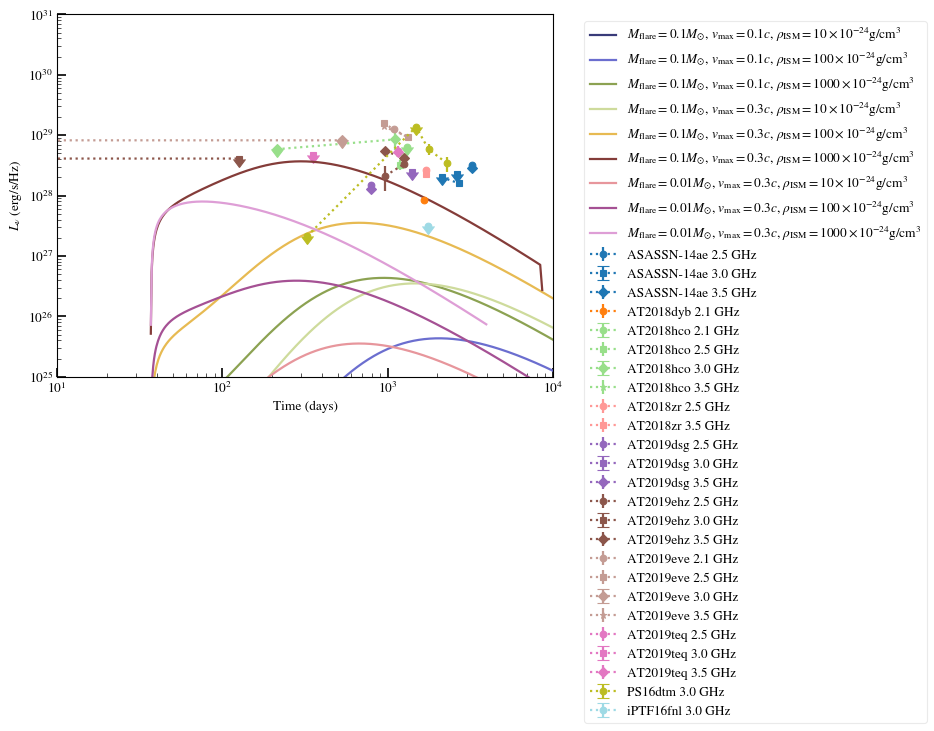

In [38]:
fig,ax = plt.subplots(figsize=(8, 6))
colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_events.keys())))
for event,color in zip(dict_events.keys(), colors_array):
    # if event != 'ASASSN-14ae':
    #     continue

    marker_array = ['o','s','D', '*','^','<','>','p','h','8']
    marker_num =0
    for freq in np.unique(dict_events[event]['freq (GHz)']):

        if np.abs(freq-3) > 1:
            continue
        freq_array = np.array([],dtype=int)
        uplims_array = np.array([],dtype=bool)
        for i in range(len(dict_events[event]['freq (GHz)'])):
            if dict_events[event]['freq (GHz)'][i] == freq:
                # print(i)
                freq_array = np.append(freq_array,i)
                if dict_events[event]['error (mJy)'][i] == 0:
                    uplims_array = np.append(uplims_array,True)
                else:
                    uplims_array = np.append(uplims_array,False)
                    
        ax.errorbar(dict_events[event]['times (d)'][freq_array], dict_events[event]['Lnu (erg/s/Hz)'][freq_array], 
                    yerr=dict_events[event]['error (erg/s/Hz)'][freq_array], fmt=marker_array[marker_num], uplims=uplims_array,  
                    ms=6, color=color, label=f'{event} {freq} GHz',linestyle=':')
        marker_num+=1
        


colors_array = plt.cm.tab20b(np.linspace(0, 1, len(datadir_constism_list)))

for i,datadir in enumerate(datadir_constism_list):

    flare2_dict = {}

    flare2_dict['Lnu_3GHz'] = np.load(datadir+'/flare2/'+'Lnu_3.00GHz_sparse_Te_1.0E+04.npz')

    flare2_dict['Lnu_10GHz'] = np.load(datadir+'/flare2/'+'Lnu_10.00GHz_sparse_Te_1.0E+04.npz')

    flare2_dict['Lnu_15GHz'] = np.load(datadir+'/flare2/'+'Lnu_15.00GHz_sparse_Te_1.0E+04.npz')

    ax.plot(flare2_dict['Lnu_3GHz']['times_yr']*365.25,(flare2_dict['Lnu_3GHz']['Lnu_abs_atfreq']),color=colors_array[i],label=names_constism_list[i])

ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(10,1e4)
ax.set_ylim(1e25,1e31)
ax.set_xlabel('Time (days)')
ax.set_ylabel(r'$L_{\nu}$ (erg/s/Hz)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')